In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from scipy.stats import linregress, pearsonr

plt.rcParams['font.sans-serif'] = "Menlo"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 22})

In [2]:
ibm_colorblind = LinearSegmentedColormap.from_list('ibm_colorblind', ['#FFB000', '#FE6100', '#DC267F', '#785EF0', '#648FFF'], N=256)

#### AUC

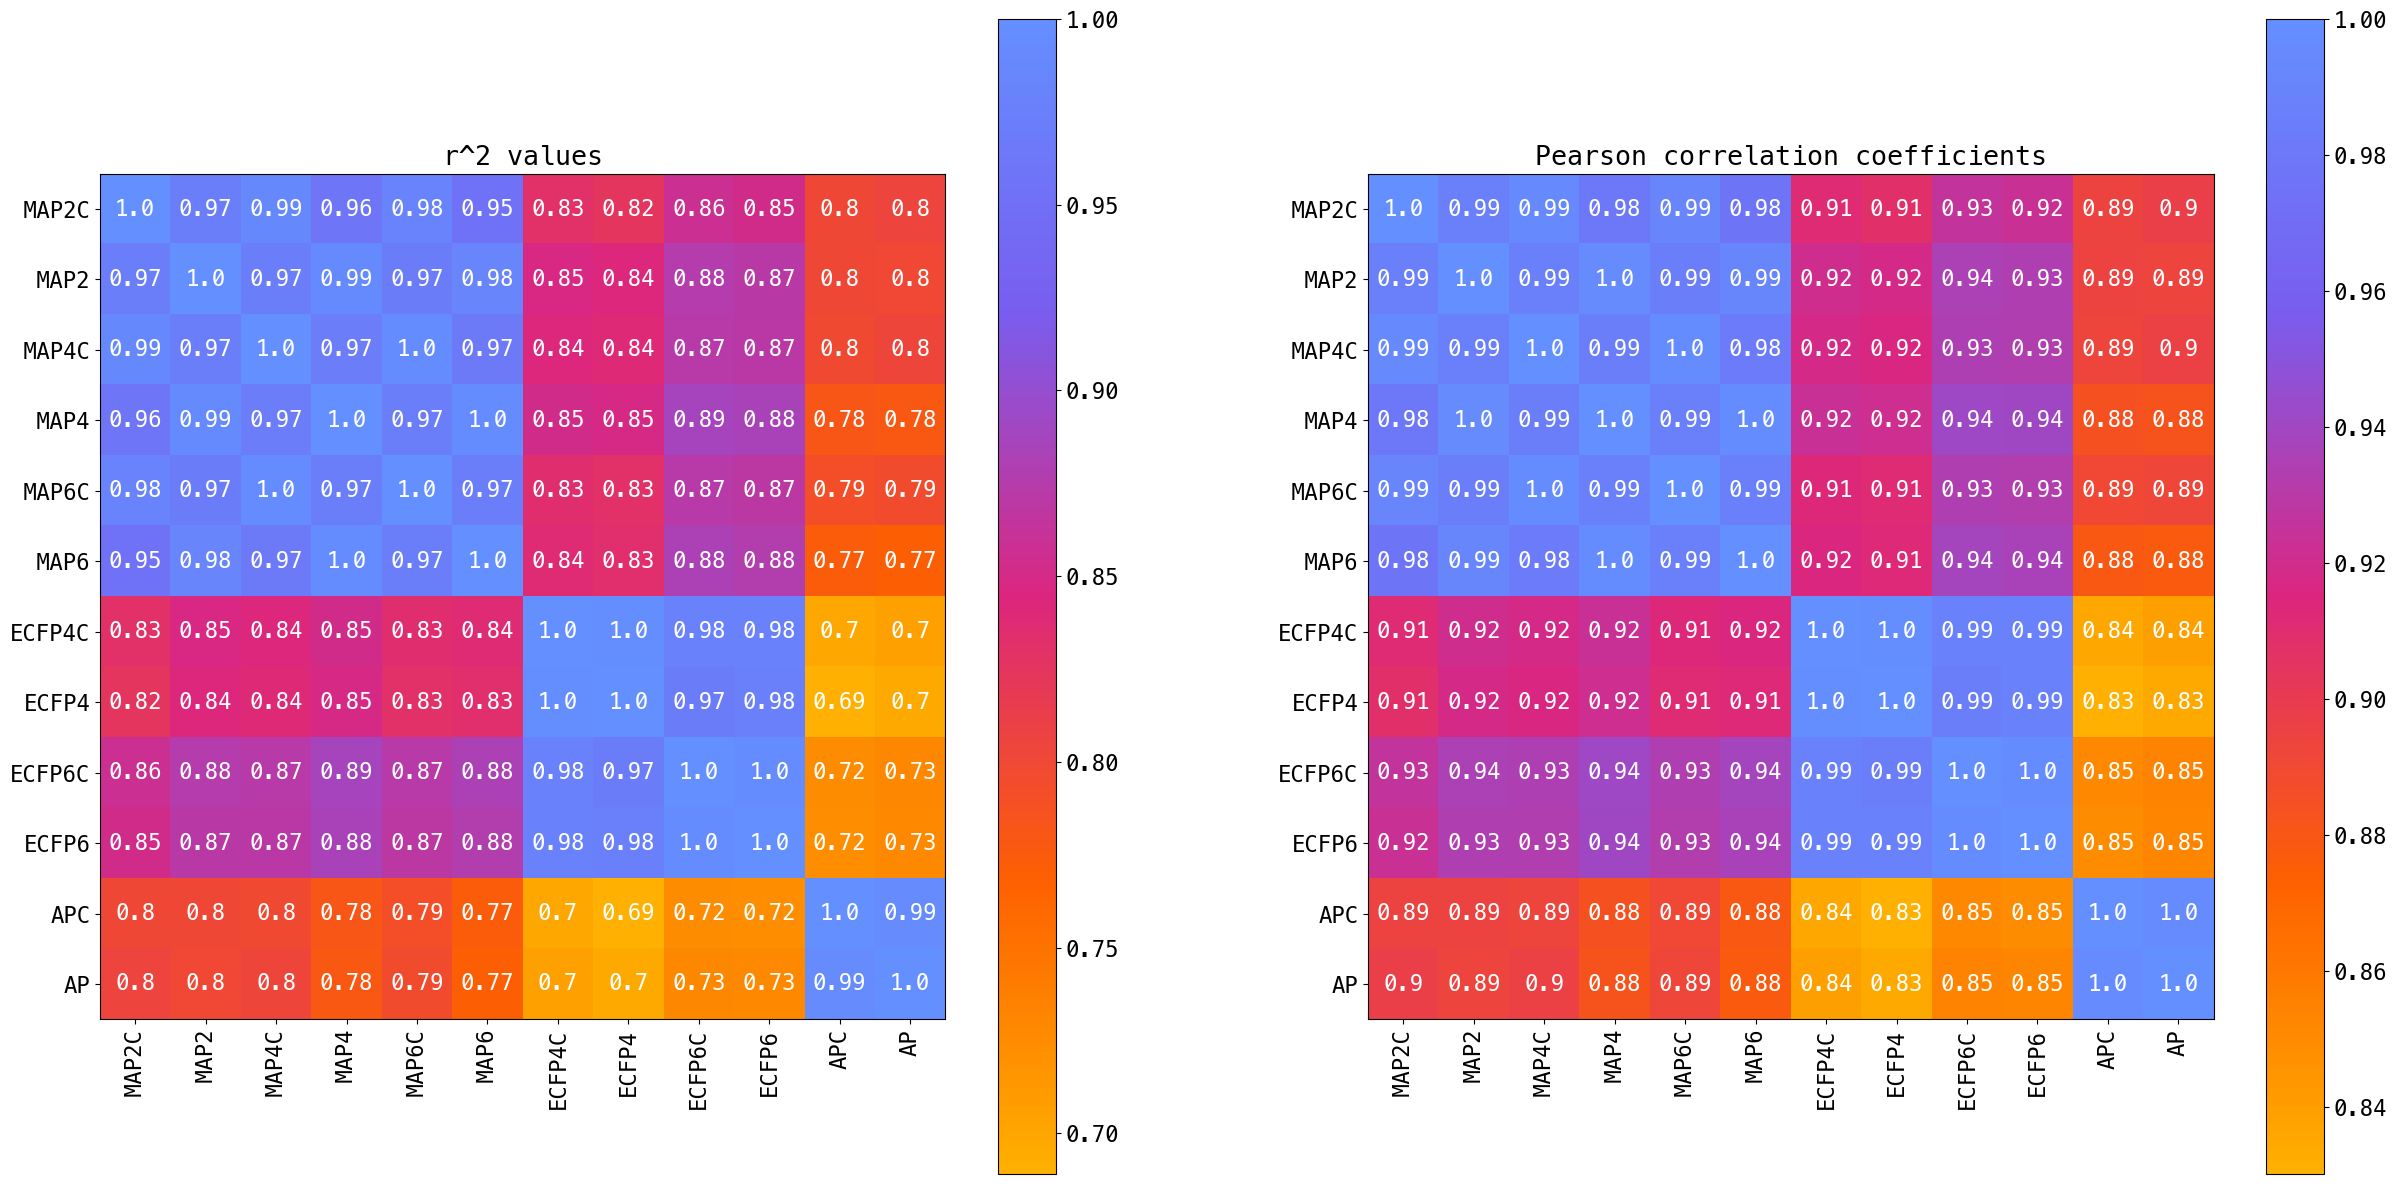

In [5]:
mean_aucs = pd.read_csv('combined_sets/auc_mean.csv')

# Pairwise r^2 values
r2s = np.zeros((len(mean_aucs.columns), len(mean_aucs.columns)))
for i, fp1 in enumerate(mean_aucs.columns):
    for j, fp2 in enumerate(mean_aucs.columns):
        regression = linregress(mean_aucs[fp1], mean_aucs[fp2])
        r2s[i][j] = regression.rvalue**2

# Pairwise Pearson correlation coefficients
pearsons = np.zeros((len(mean_aucs.columns), len(mean_aucs.columns)))
p_values = np.zeros((len(mean_aucs.columns), len(mean_aucs.columns)))
for i, fp1 in enumerate(mean_aucs.columns):
    for j, fp2 in enumerate(mean_aucs.columns):
        pearsons[i][j] = pearsonr(mean_aucs[fp1], mean_aucs[fp2])[0]
        p_values[i][j] = pearsonr(mean_aucs[fp1], mean_aucs[fp2])[1]

# Plotting two heatmaps side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']

# Plotting r^2 values
im1 = ax1.imshow(r2s, cmap=ibm_colorblind)
ax1.set_xticks(np.arange(len(mean_aucs.columns)))
ax1.set_yticks(np.arange(len(mean_aucs.columns)))
ax1.set_xticklabels(labels, rotation=90)
ax1.set_yticklabels(labels)
ax1.set_title("r^2 values")

# Plotting Pearson correlation coefficients
im2 = ax2.imshow(pearsons, cmap=ibm_colorblind)
ax2.set_xticks(np.arange(len(mean_aucs.columns)))
ax2.set_yticks(np.arange(len(mean_aucs.columns)))
ax2.set_xticklabels(labels, rotation=90)
ax2.set_yticklabels(labels)
ax2.set_title("Pearson correlation coefficients")

# Add values to heatmap
for i in range(len(mean_aucs.columns)):
    for j in range(len(mean_aucs.columns)):
        text1 = ax1.text(j, i, round(r2s[i, j], 2), ha="center", va="center", color="white")
        text2 = ax2.text(j, i, round(pearsons[i, j], 2), ha="center", va="center", color="white")

# Show colorbar
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)

plt.savefig('plots/fingerprint_correlations_aucs.png', dpi=1200, bbox_inches='tight')